<a href="https://colab.research.google.com/github/alaae2007/CST184/blob/main/Week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
  Region Energy_Type  CO2_Emissions
0   Asia       Solar           0.79
1   Asia       Solar           2.46
2   Asia       Solar           2.77
3   Asia       Solar           3.21
4   Asia       Solar           3.51

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Region         90 non-null     object 
 1   Energy_Type    90 non-null     object 
 2   CO2_Emissions  90 non-null     float64
dtypes: float64(1), object(2)
memory usage: 2.2+ KB

Statistical summary:
       CO2_Emissions
count      90.000000
mean        3.574000
std         1.434337
min         0.300000
25%         2.680000
50%         3.505000
75%         4.705000
max         6.530000

Regions:
['Asia' 'Africa' 'Europe']

Energy Types:
['Solar' 'Wind' 'Hydro']

Number of regions: 3
Number of energy types: 3

Combinations (nCr): 15
Region x Energ

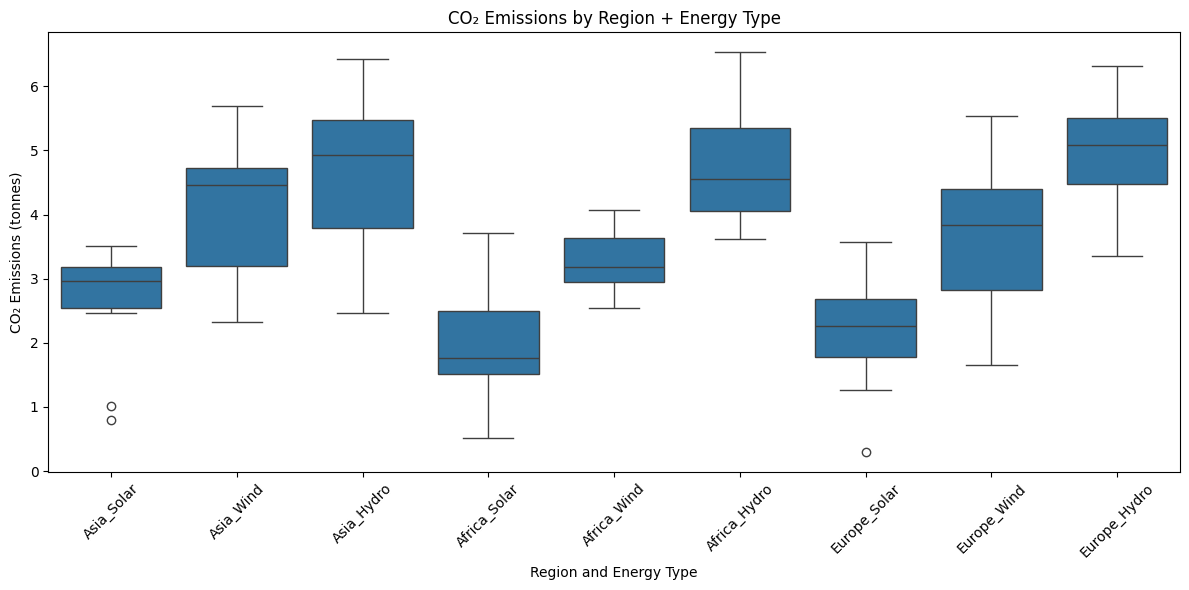


Average CO2 emissions by Region-Energy combination:
Region_Energy
Europe_Hydro    4.982
Africa_Hydro    4.753
Asia_Hydro      4.661
Asia_Wind       4.080
Europe_Wind     3.702
Africa_Wind     3.276
Asia_Solar      2.599
Europe_Solar    2.171
Africa_Solar    1.942
Name: CO2_Emissions, dtype: float64

Hydro emissions after 20% increase:
   Region Energy_Type  CO2_Emissions Region_Energy Energy_Region
20   Asia       Hydro          5.844    Asia_Hydro    Hydro_Asia
21   Asia       Hydro          7.716    Asia_Hydro    Hydro_Asia
22   Asia       Hydro          5.628    Asia_Hydro    Hydro_Asia
23   Asia       Hydro          6.636    Asia_Hydro    Hydro_Asia
24   Asia       Hydro          3.612    Asia_Hydro    Hydro_Asia


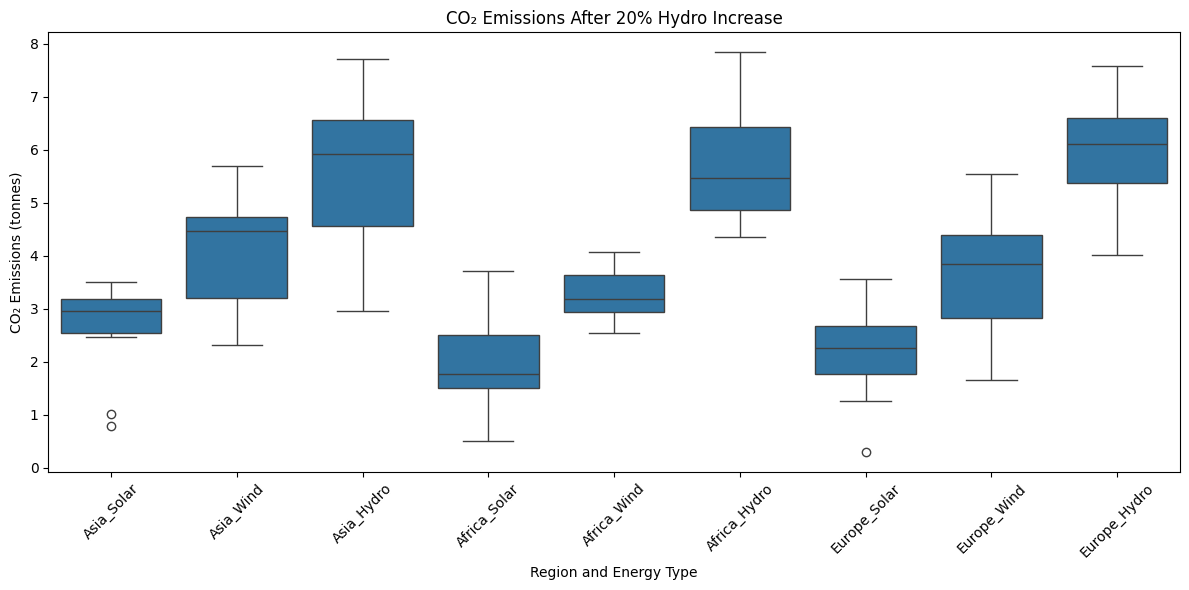


Hydro comparison:
Original average: 4.8
After 20% increase: 5.76

New Biomass row:
    Region Energy_Type  CO2_Emissions Region_Energy Energy_Region
86  Europe       Hydro          7.320  Europe_Hydro  Hydro_Europe
87  Europe       Hydro          6.000  Europe_Hydro  Hydro_Europe
88  Europe       Hydro          7.572  Europe_Hydro  Hydro_Europe
89  Europe       Hydro          6.564  Europe_Hydro  Hydro_Europe
90    Asia     Biomass          4.200  Asia_Biomass  Biomass_Asia


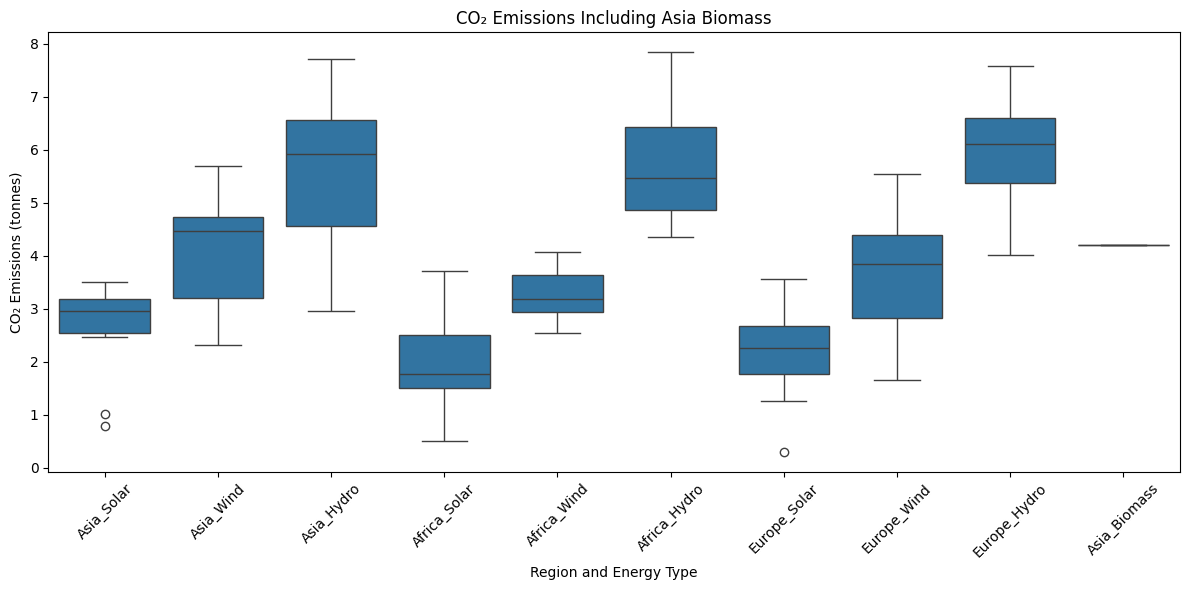


Reflection:

1. How many region-energy strategies are possible?

The original dataset contains 3 regions and 3 energy types.

Using the Cartesian product gives:

3 x 3 = 9 possible Region-Energy combinations.

When South America is added, there are:

4 x 3 = 12 combinations.

If both South America and Biomass are included, there are:

4 x 4 = 16 combinations.

This demonstrates how the number of possible strategies increases
when additional categories are introduced.


2. What does the Region_Energy feature do?

The Region_Energy column combines two categorical variables into one
new feature.

For example, Asia and Solar become Asia_Solar.

This makes it easier to group, compare and visualise emissions for
specific combinations of region and energy type.


3. What happens when Hydro emissions are increased?

Increasing Hydro emissions by 20% shifts the Hydro distributions
higher on the box plot.

The median and other values for Hydro increase, making the difference
between Hydro and t

In [2]:
# CST184 Week 4
# Counting Principles & Categorical Data Analysis
# Counting, Combinations & Box Plots

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from itertools import product


# Step 1: Load the dataset

df = pd.read_csv("week4_energy_emissions.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe())


# Step 2: Count strategy combinations

regions = df["Region"].unique()
types = df["Energy_Type"].unique()

print("\nRegions:")
print(regions)

print("\nEnergy Types:")
print(types)

print("\nNumber of regions:", len(regions))
print("Number of energy types:", len(types))

combinations = math.comb(len(regions) + len(types), 2)

print("\nCombinations (nCr):", combinations)

pairs = list(product(regions, types))

print("Region x Energy combinations:", len(pairs))

print("\nAll Region x Energy pairs:")

for pair in pairs:
    print(pair)


# Try This: Add a new region

new_regions = [
    "Asia",
    "Africa",
    "Europe",
    "South America"
]

new_pairs = list(product(new_regions, types))

print("\nAfter adding South America:")
print("Number of regions:", len(new_regions))
print("Region x Energy combinations:", len(new_pairs))

print("\nNew pairs:")

for pair in new_pairs:
    print(pair)


# Try adding a new energy type as well

new_types = [
    "Solar",
    "Wind",
    "Hydro",
    "Biomass"
]

expanded_pairs = list(product(new_regions, new_types))

print("\nAfter adding South America and Biomass:")
print("Number of regions:", len(new_regions))
print("Number of energy types:", len(new_types))
print("Region x Energy combinations:", len(expanded_pairs))


# Step 3: Create a new feature

df["Region_Energy"] = (
    df["Region"] + "_" + df["Energy_Type"]
)

print("\nDataset with Region_Energy feature:")
print(df.head(10))


# Try This: Reverse the order

df["Energy_Region"] = (
    df["Energy_Type"] + "_" + df["Region"]
)

print("\nDataset with Energy_Region feature:")
print(df.head(10))


# Show all unique Region_Energy categories

print("\nUnique Region and Energy combinations:")

print(df["Region_Energy"].unique())

print(
    "\nNumber of unique Region_Energy categories:",
    df["Region_Energy"].nunique()
)


# Step 4: Create the box plot

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Region_Energy",
    y="CO2_Emissions"
)

plt.title("CO₂ Emissions by Region + Energy Type")
plt.xlabel("Region and Energy Type")
plt.ylabel("CO₂ Emissions (tonnes)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# Calculate average emissions for each combination

average_emissions = (
    df.groupby("Region_Energy")["CO2_Emissions"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage CO2 emissions by Region-Energy combination:")
print(average_emissions)


# Step 5: Increase Hydro emissions by 20%

df_modified = df.copy()

df_modified.loc[
    df_modified["Energy_Type"] == "Hydro",
    "CO2_Emissions"
] *= 1.2

print("\nHydro emissions after 20% increase:")

print(
    df_modified[
        df_modified["Energy_Type"] == "Hydro"
    ].head()
)


# Plot the updated Hydro values

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_modified,
    x="Region_Energy",
    y="CO2_Emissions"
)

plt.title("CO₂ Emissions After 20% Hydro Increase")
plt.xlabel("Region and Energy Type")
plt.ylabel("CO₂ Emissions (tonnes)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# Compare original and modified Hydro averages

original_hydro = df[
    df["Energy_Type"] == "Hydro"
]["CO2_Emissions"].mean()

modified_hydro = df_modified[
    df_modified["Energy_Type"] == "Hydro"
]["CO2_Emissions"].mean()

print("\nHydro comparison:")
print("Original average:", round(original_hydro, 2))
print("After 20% increase:", round(modified_hydro, 2))


# Try This: Add a new category

new_row = pd.DataFrame({
    "Region": ["Asia"],
    "Energy_Type": ["Biomass"],
    "CO2_Emissions": [4.2],
    "Region_Energy": ["Asia_Biomass"],
    "Energy_Region": ["Biomass_Asia"]
})

df_modified = pd.concat(
    [df_modified, new_row],
    ignore_index=True
)

print("\nNew Biomass row:")
print(df_modified.tail())


# Plot with the new Biomass category

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_modified,
    x="Region_Energy",
    y="CO2_Emissions"
)

plt.title("CO₂ Emissions Including Asia Biomass")
plt.xlabel("Region and Energy Type")
plt.ylabel("CO₂ Emissions (tonnes)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# Reflection

print("\nReflection:")

print("""
1. How many region-energy strategies are possible?

The original dataset contains 3 regions and 3 energy types.

Using the Cartesian product gives:

3 x 3 = 9 possible Region-Energy combinations.

When South America is added, there are:

4 x 3 = 12 combinations.

If both South America and Biomass are included, there are:

4 x 4 = 16 combinations.

This demonstrates how the number of possible strategies increases
when additional categories are introduced.


2. What does the Region_Energy feature do?

The Region_Energy column combines two categorical variables into one
new feature.

For example, Asia and Solar become Asia_Solar.

This makes it easier to group, compare and visualise emissions for
specific combinations of region and energy type.


3. What happens when Hydro emissions are increased?

Increasing Hydro emissions by 20% shifts the Hydro distributions
higher on the box plot.

The median and other values for Hydro increase, making the difference
between Hydro and the other energy types easier to observe.


4. What happens when Biomass is added?

Adding Asia_Biomass creates a new category on the box plot.

Because only one Biomass observation has been added, there is not
enough data to form a meaningful distribution or full box.

More Biomass observations would be needed before making reliable
comparisons with Solar, Wind and Hydro.


5. What can we learn from the box plot?

The box plot allows us to compare the distribution of CO2 emissions
across different region and energy-type combinations.

It shows differences in the median, spread and possible unusual values
for each category.

This type of analysis could help sustainability analysts compare
different renewable energy strategies and identify patterns in
emissions across regions.
""")